In [70]:
from transformers import pipeline
from pathlib import Path 
import pandas as pd
import numpy as np
from embedding.embedding_models import *
import matplotlib.pyplot as plt
import seaborn as sns

2026-02-05 12:00:38,997|DEBUG|matplotlib data path: /home/jupyter/miniconda3/envs/jupyter-lab/lib/python3.12/site-packages/matplotlib/mpl-data
2026-02-05 12:00:39,000|DEBUG|CONFIGDIR=/home/jupyter/.config/matplotlib
2026-02-05 12:00:39,016|DEBUG|interactive is False
2026-02-05 12:00:39,016|DEBUG|platform is linux
2026-02-05 12:00:39,044|DEBUG|CACHEDIR=/home/jupyter/.cache/matplotlib
2026-02-05 12:00:39,046|DEBUG|Using fontManager instance from /home/jupyter/.cache/matplotlib/fontlist-v390.json


In [2]:
# Load the zero-shot classifier with the BART-MNLI model
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

Device set to use cuda:0


In [3]:
base_dir = Path("/data/jupyter/event_dynamics/HSMS_LUGOS/output_EL")

files = list(base_dir.rglob("in_event.csv"))

dfs = []
for f in files:
    df = pd.read_csv(f)
    df["event"] = f.parent.name
    dfs.append(df)

global_df = pd.concat(dfs, ignore_index=True)

In [28]:
# Texts to classify
sequence_to_classify = global_df["text_clean"].tolist()  # convert Series to list
test_seq = global_df.sample(frac=0.1)# Your labels
candidate_labels = [
    "CONSULT","ASSAULT","DISAPPROVE","SUPPORT","COERCE","AGREE","AID",
    "REJECT","CONCEDE","COOPERATE","RETREAT","THREATEN","DEMAND",
    "PROTEST","SANCTION","MOBILIZE"
]

In [160]:
batch_size = 16
all_results = []

for i in range(0, len(test_seq), batch_size):
    batch = test_seq[i:i+batch_size]
    batch_results = classifier(batch, candidate_labels, multi_label=True)
    all_results.extend(batch_results)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


KeyboardInterrupt: 

In [ ]:
import torch
from datasets import Dataset
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset

candidate_labels = [
    "CONSULT","ASSAULT","DISAPPROVE","SUPPORT","COERCE","AGREE","AID","REJECT",
    "CONCEDE","COOPERATE","RETREAT","THREATEN","DEMAND","PROTEST","SANCTION","MOBILIZE",
    "MAKE PUBLIC STATEMENT","APPEAL","INVESTIGATE"]

ds = Dataset.from_pandas(global_df[["text_clean"]], preserve_index=False)

device = 0 if torch.cuda.is_available() else -1
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=device,
)

preds = []
for out in classifier(
    KeyDataset(ds, "text_clean"),
    candidate_labels=candidate_labels,
    multi_label=True,
    truncation=True,
    batch_size=16,
):
    preds.append((out["labels"][0], float(out["scores"][0])))



Device set to use cuda:0


ValueError: Length of values (30788) does not match length of index (3079)

In [31]:
global_df["top_label"] = [p[0] for p in preds]
global_df["top_score"] = [p[1] for p in preds]

In [32]:
global_df

,GlobalEventID,date,Year,Actor1Code,Actor1Name,Actor1CountryCode,Actor1EthnicCode,Actor2Code,Actor2Name,Actor2CountryCode,...,norm_date,seed_hits_count,seed_hits_unique,seed_hits_detail,row_id,is_event,embedding_json,event,top_label,top_score
0,1017301168,2021-12-03,2021,USA,UNITED STATES,USA,NaN,NaN,NaN,NaN,...,-7,2,1,{'home': 2},36,True,"[-0.012463859282433987, 0.03221821039915085, 0...",tornadokentucky,INVESTIGATE,0.994718
1,1017455240,2021-12-03,2021,USA,KENTUCKY,USA,NaN,MED,WEBSITE,NaN,...,-7,0,0,{},63,True,"[0.04080123454332352, 0.07696226984262466, -0....",tornadokentucky,INVESTIGATE,0.986662
2,1017449074,2021-12-03,2021,USA,UNITED STATES,USA,NaN,NaN,NaN,NaN,...,-7,2,1,{'emergency': 2},84,True,"[-0.06117528676986694, -0.00201579462736845, 0...",tornadokentucky,CONSULT,0.864449
3,1017475972,2021-12-04,2021,USA,UNITED STATES,USA,NaN,NaN,NaN,NaN,...,-6,0,0,{},97,True,"[0.03217422962188721, -0.03891298174858093, 0....",tornadokentucky,RETREAT,0.971768
4,1017513258,2021-12-04,2021,USA,UNITED STATES,USA,NaN,NaN,NaN,NaN,...,-6,0,0,{},113,True,"[-0.031463488936424255, 0.06948555260896683, 0...",tornadokentucky,MAKE PUBLIC STATEMENT,0.991547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30783,1049403382,2022-06-14,2022,CVL,COMMUNITY,NaN,NaN,NaN,NaN,NaN,...,31,4,2,"{'gun': 2, 'violence': 2}",14999,True,"[0.004389178939163685, -0.03833003714680672, -...",buffaloshooting,CONSULT,0.962938
30784,1049367734,2022-06-14,2022,COP,STATE PRISON,NaN,NaN,NaN,NaN,NaN,...,31,3,2,"{'gun': 1, 'victim': 2}",15013,True,"[0.025666305795311928, 0.05196196585893631, 0....",buffaloshooting,CONSULT,0.961928
30785,1049361041,2022-06-14,2022,RUS,RUSSIAN,RUS,NaN,UKR,UKRAINE,UKR,...,31,5,3,"{'mass': 3, 'victim': 1, 'white': 1}",15059,True,"[0.02697603777050972, -0.009075000882148743, -...",buffaloshooting,SUPPORT,0.985491
30786,1049381582,2022-06-14,2022,USA,UNITED STATES,USA,NaN,MED,MAGAZINE,NaN,...,31,4,3,"{'mass': 1, 'shooting': 1, 'gun': 2}",15066,True,"[-0.026762794703245163, -0.01038440503180027, ...",buffaloshooting,SUPPORT,0.996092


In [17]:
test_seq['top_label'].unique()

array(['CONSULT', 'APPEAL', 'SUPPORT', 'CONCEDE', 'DEMAND', 'RETREAT',
       'THREATEN', 'COERCE', 'PROTEST', 'INVESTIGATE',
       'MAKE PUBLIC STATEMENT', 'DISAPPROVE', 'AID', 'REJECT', 'ASSAULT',
       'COOPERATE', 'SANCTION', 'AGREE', 'MOBILIZE'], dtype=object)

In [34]:
cameo_2_plover = {
    "01":"MAKE PUBLIC STATEMENT",
    "02": "APPEAL",
    "03": "AGREE",
    "04": "CONSULT",
    "05": "SUPPORT",
    "06": "COOPERATE",
    "07": "AID",
    "81": "CONCEDE",
    "84": "RETREAT",
    "09": "INVESTIGATE",
    "10": "DEMAND",
    "11": "DISAPPROVE",
    "12": "REJECT",
    "13": "THREATHEN",
    "14": "PROTEST",
    "15": "MOBILIZE",
    "16": "SANCTION",
    "17": "COERCE",
    "18": "ASSAULT",
    "19": "ASSAULT",
    "20": "ASSAULT"

}


def make_plover_codes(df: pd.DataFrame):
    """
    Make a Plover column from CAMEO's event codes.
    """
    evtcode_padded = df['EventBaseCode'].astype(str).str.zfill(3)
    # Replace 081-083 with 8.1 ("CONCEDE")
    evtcode_padded = evtcode_padded.str.replace(r"08[0-3]", "81", n=1, regex=True)
    evtcode_padded = evtcode_padded.str.replace(r"08[4-7]", "84", n=1, regex=True)
    
    plover_codes = evtcode_padded.str[:2].apply(lambda s: cameo_2_plover[s])
    return plover_codes

global_df['PloverCode'] = make_plover_codes(global_df)

In [44]:
global_df.to_csv('globaldf_02052026.csv')

In [38]:
mask = global_df["top_label"] == global_df["PloverCode"]
count_equal = mask.sum()



In [39]:
event_counts = (
    global_df.loc[mask]
      .groupby("event")
      .size()
      .reset_index(name="count")
)


In [41]:
ratio = mask.value_counts(normalize=True)


In [42]:
ratio

False    0.883656
True     0.116344
Name: proportion, dtype: float64

In [62]:
def make_sampler(
    df: pd.DataFrame,
    num: int,
    col: str = "embedding_json",
    look_col: str = "top_label",
    balanced: bool = True
):
    df = df.copy()

    # Make sure labels are clean strings
    df[look_col] = df[look_col].fillna("").astype(str)

    all_idx = np.arange(len(df), dtype=int)

    # label -> row indices
    label_to_rows = {}
    for idx, lab in enumerate(df[look_col].values):
        label_to_rows.setdefault(lab, []).append(idx)
    for lab in label_to_rows:
        label_to_rows[lab] = np.asarray(label_to_rows[lab], dtype=int)

    def sample_positive_j(i_idx: int, rng: np.random.RandomState) -> int:
        lab = df.iloc[i_idx][look_col]
        cand = label_to_rows.get(lab, np.array([], dtype=int))
        cand = cand[cand != i_idx]  # avoid same row
        if len(cand) == 0:
            # fallback: any other row (will become y=0)
            cand = all_idx[all_idx != i_idx]
        return int(rng.choice(cand))

    def sample_negative_j(i_idx: int, rng: np.random.RandomState, max_tries: int = 50) -> int:
        lab = df.iloc[i_idx][look_col]
        cand_all = all_idx[all_idx != i_idx]

        for _ in range(max_tries):
            j_idx = int(rng.choice(cand_all))
            if df.iloc[j_idx][look_col] != lab:
                return j_idx

        # brute force fallback
        for j_idx in cand_all:
            if df.iloc[j_idx][look_col] != lab:
                return int(j_idx)

        # degenerate case: only one label exists
        return int(rng.choice(cand_all))

    rng_i = np.random.RandomState(42)
    rng_pos = np.random.RandomState(0)
    rng_neg = np.random.RandomState(13)

    if not balanced:
        i = df.sample(n=num, random_state=42, replace=True).reset_index(drop=True)
        j = df.sample(n=num, random_state=1, replace=True).reset_index(drop=True)
    else:
        n_pos = num // 2
        n_neg = num - n_pos

        i_pos_idx = rng_i.choice(all_idx, size=n_pos, replace=True)
        i_neg_idx = rng_i.choice(all_idx, size=n_neg, replace=True)

        j_pos_idx = np.array([sample_positive_j(ii, rng_pos) for ii in i_pos_idx])
        j_neg_idx = np.array([sample_negative_j(ii, rng_neg) for ii in i_neg_idx])

        i_idx = np.concatenate([i_pos_idx, i_neg_idx])
        j_idx = np.concatenate([j_pos_idx, j_neg_idx])

        i = df.iloc[i_idx].reset_index(drop=True)
        j = df.iloc[j_idx].reset_index(drop=True)

    # Enforce not same GlobalEventID
    same_gid = (i["GlobalEventID"].values == j["GlobalEventID"].values)
    if same_gid.any():
        for k in np.where(same_gid)[0]:
            cand = df[df["GlobalEventID"] != i.loc[k, "GlobalEventID"]]
            j.loc[k] = cand.sample(n=1, random_state=999+k, replace=True).iloc[0]

    # ✅ y = 1 iff labels match
    y = (i[look_col].values == j[look_col].values).astype(int)

    sampler = pd.DataFrame({
        "GlobalEventID-i": i["GlobalEventID"],
        "GlobalEventID-j": j["GlobalEventID"],
        "features-i": i[col],
        "features-j": j[col],
        f"{look_col}-i": i[look_col],
        f"{look_col}-j": j[look_col],
        "y": y
    })

    return sampler



False    0.883656
True     0.116344
Name: proportion, dtype: float64

In [63]:
def vectorize(series):
    """
    Takes a pandas Series of embedding_json strings
    and returns a NumPy array of shape (N, 384).
    """
    # Ensure string
    s = series.astype(str).str.strip()

    # Remove brackets, split into float lists
    vecs = (
        s.str[1:-1]                   # strip '[' and ']'
         .str.split(',')              # split by comma
         .apply(lambda x: np.array(x, dtype=np.float32))
         .tolist()
    )

    # Stack into (n_samples, embed_dim)
    return np.vstack(vecs)

In [92]:
sample = make_sampler(global_df,10000,balanced=False)

In [93]:
print(f"Input training data: {len(global_df)} articles.")
print(f"Training pairs: {len(sample)}")
print(f"  {sample.value_counts('y')}")

Input training data: 30788 articles.
Training pairs: 10000
  y
0    7666
1    2334
Name: count, dtype: int64


In [94]:

i_np = vectorize(sample["features-i"])
j_np = vectorize(sample["features-j"])
i = torch.from_numpy(i_np)
j = torch.from_numpy(j_np)
# Random labels: 0 if dissimilar, 1 if similar.
#make the labels if similar 1, 0 if not
labels = torch.tensor(sample["y"].values, dtype=torch.float32)



In [95]:
input_dim = 384  # Just like SBERT embeddings
embed_dim = 100  # Chosen embedding dimension
margin = 1.0  # Choose a margin
batch_size=36  # the batch size
n_epochs = 40  # the number of epochs
lr = 0.1  # the learning rate

dataset = ContrastiveDataset(i, j, labels)
model, loss = train_contrastive_loss(dataset, embed_dim, margin=margin,
                                     dist_func=cosine_distance, 
                                     batch_size=batch_size,
                                     epochs=n_epochs,
                                     lr=lr
                                     )
logger.info(f"Model trained!")

2026-02-05 12:15:46,065|DEBUG|Epoch 1/40, Loss: 0.2452
2026-02-05 12:15:46,253|DEBUG|Epoch 2/40, Loss: 0.1746
2026-02-05 12:15:46,441|DEBUG|Epoch 3/40, Loss: 0.1529
2026-02-05 12:15:46,629|DEBUG|Epoch 4/40, Loss: 0.1413
2026-02-05 12:15:46,817|DEBUG|Epoch 5/40, Loss: 0.1327
2026-02-05 12:15:47,005|DEBUG|Epoch 6/40, Loss: 0.1267
2026-02-05 12:15:47,192|DEBUG|Epoch 7/40, Loss: 0.1220
2026-02-05 12:15:47,380|DEBUG|Epoch 8/40, Loss: 0.1180
2026-02-05 12:15:47,568|DEBUG|Epoch 9/40, Loss: 0.1152
2026-02-05 12:15:47,755|DEBUG|Epoch 10/40, Loss: 0.1122
2026-02-05 12:15:47,943|DEBUG|Epoch 11/40, Loss: 0.1105
2026-02-05 12:15:48,132|DEBUG|Epoch 12/40, Loss: 0.1087
2026-02-05 12:15:48,320|DEBUG|Epoch 13/40, Loss: 0.1068
2026-02-05 12:15:48,508|DEBUG|Epoch 14/40, Loss: 0.1051
2026-02-05 12:15:48,695|DEBUG|Epoch 15/40, Loss: 0.1040
2026-02-05 12:15:48,883|DEBUG|Epoch 16/40, Loss: 0.1022
2026-02-05 12:15:49,070|DEBUG|Epoch 17/40, Loss: 0.1016
2026-02-05 12:15:49,258|DEBUG|Epoch 18/40, Loss: 0.1005
2

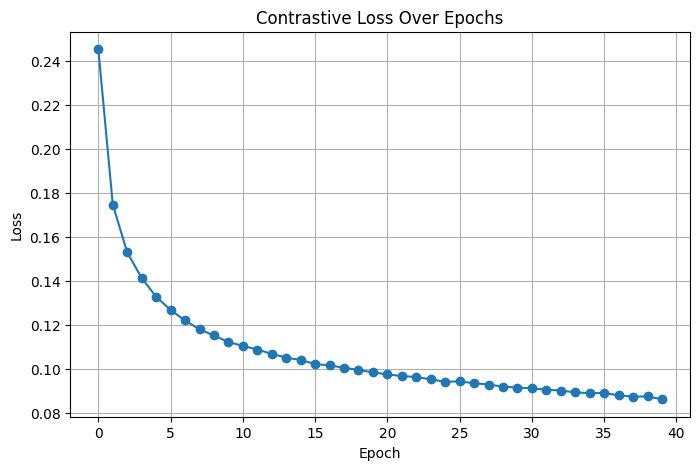

In [96]:
plt.figure(figsize=(8, 5))
plt.plot(loss, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Contrastive Loss Over Epochs")
plt.grid(True)
plt.show()

In [97]:
def avg_pairwise_distance_by_label(x1, x2, labels, metric="cosine"):
    """
    Works with BOTH numpy arrays and torch tensors.
    Computes avg distance for same-label and opposite-label pairs.
    """

    # --- Convert everything to torch tensors if needed ---
    if isinstance(x1, np.ndarray):
        x1 = torch.from_numpy(x1)
    if isinstance(x2, np.ndarray):
        x2 = torch.from_numpy(x2)
    if isinstance(labels, np.ndarray):
        labels = torch.from_numpy(labels)

    x1 = x1.float()
    x2 = x2.float()
    labels = labels.int()

    # --- Distance computation ---
    if metric == "cosine":
        x1n = F.normalize(x1, p=2, dim=1)
        x2n = F.normalize(x2, p=2, dim=1)
        distances = 1 - torch.sum(x1n * x2n, dim=1)

    elif metric == "euclidean":
        distances = torch.norm(x1 - x2, dim=1)

    else:
        raise ValueError("metric must be 'cosine' or 'euclidean'")

    distances = distances.cpu().numpy()
    labels = labels.cpu().numpy()

    same_mask = labels == 1
    opp_mask  = labels == 0

    same_dist = distances[same_mask]
    opp_dist = distances[opp_mask]

    avg_same = distances[same_mask].mean() if same_mask.any() else np.nan
    avg_opp  = distances[opp_mask].mean() if opp_mask.any() else np.nan
    
    return same_dist, opp_dist,{
        "avg_same": float(avg_same),
        "avg_opposite": float(avg_opp),
        "n_same": int(same_mask.sum()),
        "n_opposite": int(opp_mask.sum())
    }

In [98]:
model.eval()

with torch.no_grad():
    i_embed = model(i).cpu().numpy()   # shape: (N, embed_dim)
    j_embed = model(j).cpu().numpy()   # shape: (N, embed_dim)
    
all_embeddings = np.vstack([i_embed, j_embed])

global_ids = np.concatenate([sample["GlobalEventID-i"].values,
                             sample["GlobalEventID-j"].values])

eventcodes = np.concatenate([
    sample["top_label-i"].astype(str),
    sample["top_label-j"].astype(str)
])


all_labels = np.concatenate([labels.numpy(), labels.numpy()])
pair_flag   = np.array([0]*len(i_embed) + [1]*len(j_embed))  # blue = i, orange = j

In [99]:
sbert_same_dist, sbert_opp_dist, stats_sbert_35000 = avg_pairwise_distance_by_label(i, j, labels, metric="cosine")

# Learned embeddings
learned_same_dist, learn_opp_dist, stats_learned_35000 = avg_pairwise_distance_by_label(i_embed, j_embed, labels, metric="cosine")

In [100]:
data_learned_same = list()
data_learned_opp = list()
learned_values_same = np.array(learned_same_dist, dtype=float) 
data_learned_same.extend([(f, v) for v in learned_values_same]) 
learned_values_opp = np.array(learn_opp_dist, dtype=float) 
data_learned_opp.extend([(f, v) for v in learn_opp_dist])
df_same = pd.DataFrame(data_learned_same, columns=["file", "distance"])
df_same["group"] = "same"

df_opp = pd.DataFrame(data_learned_opp, columns=["file", "distance"])
df_opp["group"] = "opp"

df_learned = pd.concat([df_same, df_opp], ignore_index=True)

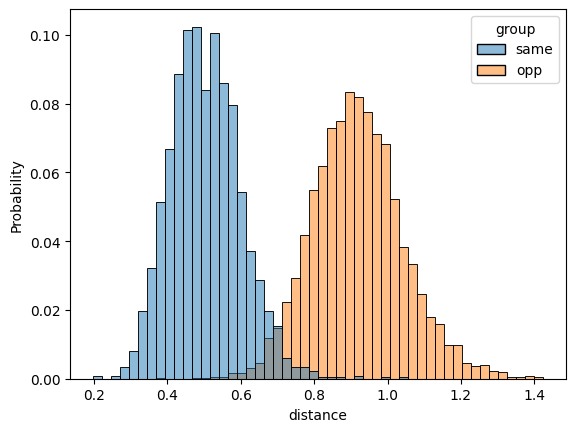

<Figure size 640x480 with 0 Axes>

In [101]:
sns.histplot(
    data=df_learned,
    x="distance",
    hue="group",              # <-- this is the key change
    stat="probability",
    common_norm=False,
    bins=50
)

plt.show()
plt.clf()
